In [1]:
import sys 

sys.path.append("../../src/")
from project_imports import *

import numerical_quenches as nq 

from numerical_quenches import groundstate

import TFIM_operators_from_states as op

In [2]:

def P_vector(n,states):
    return array([op.Px_n(n,s) for s in states])

def Pz_vector(n,states):
    return array([op.Pz_n(n,s) for s in states])
def g_hold(t,args):
    gf= args
    return gf
def nks(state_initial, state_final):
    ui, vi, _ = state_initial
    uf, vf, _ = state_final

    # This is the amplitude of the 'excited' component
    # equivalent to sin^2(delta_theta / 2)
    nk = np.abs(uf * vi - vf * ui)**2 
    return nk

In [6]:
# Instant Quench 
L = 100
g0=10
gf = 1/4

psi_0= nq.groundstate(g0,L)
psi_f = nq.groundstate(gf,L)
t = np.linspace(0,10*pi,1000)
states = nq.states(L,t,g_hold,gf,psi_0)

plot(lks(nks(psi_0,psi_f)))

g0=0.25


NameError: name 'lks' is not defined

In [7]:

################################################
#                   IMPORTS
################################################
from project_imports import * 
################################################
#           HELPFUL FUNCTIONS
################################################
def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def Pfaffian(M):
    """
    Compute the Pfaffian of an antisymmetric matrix M.
    M must be (2N x 2N) and antisymmetric.
    ChatGPT wrote this....
    """
    M = np.array(M, dtype=complex)
    n = M.shape[0]

    if n % 2 != 0:
        return 0.0

    pf = 1.0 + 0j
    A = M.copy()

    for k in range(0, n-1, 2):
        # find a nonzero pivot
        if abs(A[k, k+1]) < 1e-14:
            swap_found = False
            for l in range(k+2, n):
                if abs(A[k, l]) > 1e-14:
                    # swap columns k+1 and l
                    A[:, [k+1, l]] = A[:, [l, k+1]]
                    A[[k+1, l], :] = A[[l, k+1], :]
                    pf *= -1
                    swap_found = True
                    break
            if not swap_found:
                return 0.0

        pf *= A[k, k+1]

        for i in range(k+2, n):
            for j in range(i+1, n):
                A[i, j] -= (
                    A[k, i]*A[k+1, j] - A[k, j]*A[k+1, i]
                ) / A[k, k+1]
                A[j, i] = -A[i, j]

    return pf


################################################
#           TFIM FUNCTIONS
################################################

# note: I had an EXTREMELY tough time on this one. Pay attention to the signs and phase of the terms! G must be a real def
# 
def G(r, state_gge):
    """
    state_gge = [u_f, v_f, k, nk]
    Calculates the GGE expectation value of {bi, aj}
    """
    u, v, k, nk = state_gge
    # The GGE weight: for nk=0 (ground state), weight=1. For nk=0.5 (infinite temp), weight=0.
    weight = (1 - 2 * nk)
    
    # Core kernel weighted by the quasiparticle distribution
    Gr = 2*np.cos(k*r)*(np.abs(u)**2 - np.abs(v)**2) - 2j*np.sin(k*r)*(np.conj(u)*v - np.conj(v)*u)
    
    return -np.mean(Gr * weight) / 2

def GA(r, state_gge):
    """
    Calculates the GGE expectation value of {ai, aj}
    Note: GA(0) should be 1.0 (anti-commutation {ai, ai} = 2, so correlation is 1)
    """
    u, v, k, nk = state_gge
    # For GA and GB, notice the (u^2 + v^2) term is the identity part
    # In a typical GGE quench, GA and GB often remain delta functions delta_{ij}
    # unless the quench involves more complex symmetries.
    Gr = 2*np.cos(k*r)*(np.abs(u)**2 + np.abs(v)**2) + 2j*np.sin(k*r)*(np.conj(u)*v + np.conj(v)*u)
    
    # We apply the mean across the k-modes
    return -np.mean(Gr) / 2

def GB(r, state_gge):
    """
    Calculates the GGE expectation value of {bi, bj}
    """
    u, v, k, nk = state_gge
    Gr = 2*np.cos(k*r)*(np.abs(u)**2 + np.abs(v)**2) - 2j*np.sin(k*r)*(np.conj(u)*v + np.conj(v)*u)
    
    return -np.mean(Gr) / 2
################################################
#           Majorna Correlators
################################################
def Majorana_String_single_pair_X(pair):
    """
    Helper Function
    pair = [i, j] with i < j
    Returns the Majorana string as a list of ("A"/"B", site) tuples.
    For X projectors, any two sites are connected with a string of majorana fermions. 
   < B_i \sum (Aj Bj) A_f>
    """
    i, j = pair
    #Start the string
    string = [("B", i)]
    for s in range(i + 1, j):
        #Add z terms
        string.append(("A", s))
        string.append(("B", s))
    #End string
    string.append(("A", j))
    return string
def Create_Majorana_Strings_Z(indices):
    """Helper Function
    For Z projectors, any site simply contributes a pair of Majorna Fermions
    <(B0A0)(B1A1)...>
    """
    string = []
    for i in indices:
        #Add z terms
        string.append(("B", i))
        string.append(("A", i))
    return string

def Create_Majorana_Strings_X(pairs):
    """Helper Function
   Connects pairs of indices to create a full majorana string for sigma x operators.
    """
    lst=[]
    for pair in pairs:
        lst+= Majorana_String_single_pair_X(pair)
    return lst

def Majorana_Correlation(a,b,state):
    """Computes correlation of any two Majorana fermions
    Fermions must be in the form a= ("A/B",index)
    """
    #Unpack Variables
    S1,i = a
    S2,j = b

    if S1=="A" and S2=="A":
        #This minus sign proves to be right though it bothers me... check <sigma_0 sigma_j> in a quench to hf=0 to verify.
        return -GA(j-i,state) 
    elif S1=="A" and S2=="B":
        return -G(i-j,state)
    elif S1=="B" and S2=="A":
        return G(j-i,state)
    else:
        return GB(j-i,state) 

def Majorana_Covariance(Majorana_String,state):
    """
    Creates a covariance matrix out of a string of Majorna operators, the pfaffian of which is expectation value of the string using wick contractions.
    If you don't use the pfaffian, there are actually some problems with using sqrt(det(M))!
    """
    N = len(Majorana_String)
    M = np.zeros((N,N),dtype=complex)
    for a in range(N):
        for b in range(N):
            if a < b:
                M1,M2= Majorana_String[a], Majorana_String[b]
                M[a, b] = Majorana_Correlation(M1, M2,state)
                #Matrix is anti-symmetric
                M[b, a] = -M[a, b]
    return M 

################################################
#           X Operators
################################################

# def sx_correlation(indices,state):
#     """
#     Computes the correlation of a string of sigma_x operators at sites labeled by indices. 
#     This code commutes them into an ordered form (sigma_i<sigma_j<..)
#     Then evaluates the expectation through the use of Majorana Fermions
#     """
#     #Remove Duplicates, sort (allowed via commutation algebra and sigma^2=1)
#     indices = list(set(indices))
#     #If there is an odd number of sites, return 0.
#     if len(indices)%2==1:
#         return 0
#     #Seperate indices into pairs
#     pairs = [indices[i:i+2] for i in range(0, len(indices), 2)]
#     #Create full Majorna String
#     Majorana_String = Create_Majorana_Strings_X(pairs)
#     #Create full Covariance Matrix
#     Majorana_cov = Majorana_Covariance(Majorana_String,state)
#     #Evaluate expectation with Pfaffian
#     return Pfaffian(Majorana_cov)


def sx_correlation(indices, state):
    """
    Computes the correlation of a string of sigma_x operators at sites labeled by indices. 
    This code commutes them into an ordered form (sigma_i<sigma_j<..)
    Then evaluates the expectation through the use of Majorana Fermions
    """
    #Remove duplicates by annihilating pairs (sigma^2=1), then sort
    counts = Counter(indices)
    indices = sorted([i for i, c in counts.items() if (c % 2) == 1])

    #If there is an odd number of sites, return 0.
    if len(indices) % 2 == 1:
        return 0

    #Trivial identity (empty string)
    if len(indices) == 0:
        return 1

    #Seperate indices into pairs
    pairs = [indices[i:i+2] for i in range(0, len(indices), 2)]

    #Create full Majorna String
    Majorana_String = Create_Majorana_Strings_X(pairs)

    #Create full Covariance Matrix
    Majorana_cov = Majorana_Covariance(Majorana_String, state)

    #Evaluate expectation with Pfaffian
    return Pfaffian(Majorana_cov)

def Px_n(n,state):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            dat.append(0)
        else:
            dat.append(sx_correlation(indices,state)*degen)
    #Manually add the 1 
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n



def Px_n_correlations(n,l,state, even = True):
    """<P_n P_n(r)>"""
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            dat.append(0)
       
        else:
            dat.append(sx_correlation(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


################################################
#           Z Operators
################################################
# def sz_correlation(indices,state):
#     """
#     Computes the correlation of a string of sigma_x operators at sites labeled by indices. 
#     This code commutes them into an ordered form (sigma_i<sigma_j<..)
#     Then evaluates the expectation through the use of Majorana Fermions
#     """
#     #Remove Duplicates, sort (allowed via commutation algebra and sigma^2=1)
#     indices = list(set(indices))
#     #Create full Majorna String
#     Majorana_String = Create_Majorana_Strings_Z(indices)
#     #Create full Covariance Matrix
#     Majorana_cov = Majorana_Covariance(Majorana_String,state)
#     #Evaluate expectation with Pfaffian
#     return Pfaffian(Majorana_cov)


def sz_correlation(indices,state):
    """
    Computes the correlation of a string of sigma_z operators at sites labeled by indices. 
    This code commutes them into an ordered form (sigma_i<sigma_j<..)
    Then evaluates the expectation through the use of Majorana Fermions
    """
    #Remove duplicates via sigma^2 = 1 and sort
    counts = Counter(indices)
    indices = sorted([i for i,c in counts.items() if c % 2 == 1])

    #Identity operator
    if len(indices) == 0:
        return 1

    #Create full Majorna String
    Majorana_String = Create_Majorana_Strings_Z(indices)

    #Create full Covariance Matrix
    Majorana_cov = Majorana_Covariance(Majorana_String,state)

    #Evaluate expectation with Pfaffian
    return Pfaffian(Majorana_cov)

def Pz_n(n,state):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    

    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sz_correlation(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

#P_n correlations do not calculate connected correlator at all
def Pz_n_correlations(n,l,state):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sz_correlation(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [127]:
n=nks(psi_0,psi_f)

y= [psi_f[0],psi_f[1],psi_f[2],n]

In [128]:
Px_n(2,y)

np.complex128(0.29333347626649886+0j)

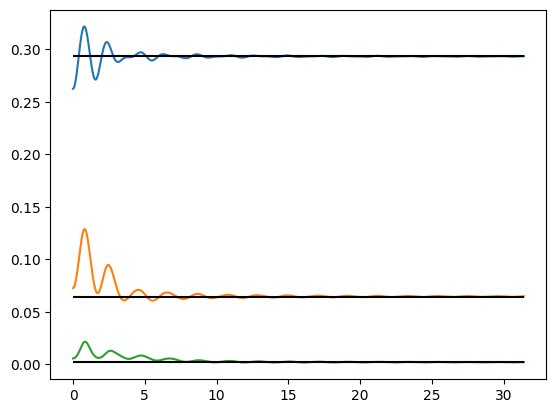

In [129]:
plot(t,P_vector(2,states))
plt.hlines(Px_n(2,y),t[0],t[-1],color="black")



plot(t,P_vector(4,states))
plt.hlines(Px_n(4,y),t[0],t[-1],color="black")


plot(t,P_vector(8,states))
plt.hlines(Px_n(8,y),t[0],t[-1],color="black")


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


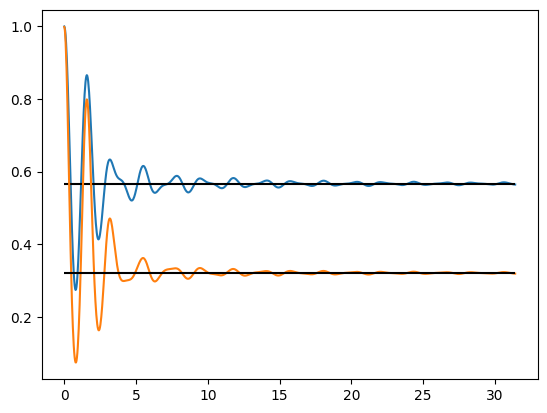

In [132]:
plot(t,Pz_vector(2,states))
plt.hlines(Pz_n(2,y),t[0],t[-1],color="black")



plot(t,Pz_vector(4,states))
plt.hlines(Pz_n(4,y),t[0],t[-1],color="black")


In [8]:
def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 25*np.pi, 200)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free
def calculate_gge_entropy(nk):
    """
    Computes the total GGE entropy from occupation numbers nk.
    Note: nk must be between 0 and 1. 
    We add a small epsilon to avoid log(0).
    """
    eps = 1e-15
    # Clamp values to avoid numerical instability
    nk = np.clip(nk, eps, 1 - eps)
    
    # Binary entropy per mode
    sk = -(nk * np.log(nk) + (1 - nk) * np.log(1 - nk))
    
    # Return total entropy (sum over all k)
    return np.sum(sk)

g0=1.0
g0=0.0
[0.00186172-0.j]


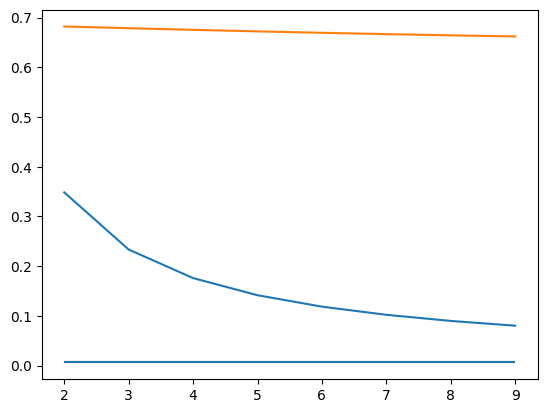

In [ ]:

s=states[0]
n=nks(s,psi_f)
s =(calculate_gge_entropy(n)/L)
s2 =states[-1]
print(-log(2*P_vector(2,[s2]))/2)



GGE_State= [psi_f[0],psi_f[1],psi_f[2],n]

ns= np.arange(2,10)
dat = [-log(Px_n(n,GGE_State))/n for n in ns]

plot(ns,dat)
plt.hlines(s,ns[0],ns[-1])
dat = [-log(Pz_n(n,GGE_State))/n for n in ns]

plot(ns,dat)
plt.hlines(s,ns[0],ns[-1])

g0=1.0
g0=0.25
[0.0083235-0.j]
g0=1.0
g0=0.25
[0.07375564-0.j]


Text(0.5, 1.0, '$-\\log(\\langle P^x_n \\rangle _{GGE})/n$ converges to entropy')

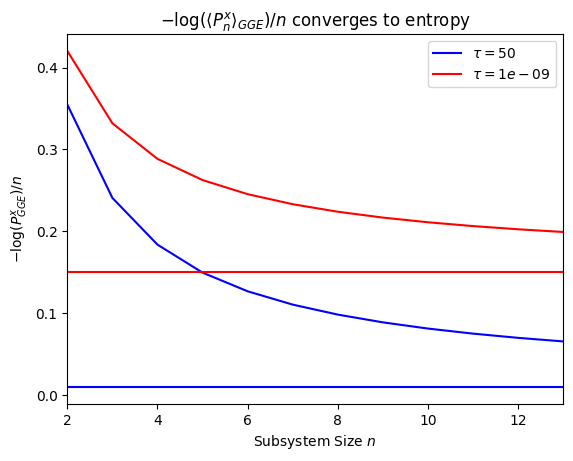

In [384]:
# Slow Quench 
L = 500
tau = 50
g0=4
gf = 1/4

psi_0= nq.groundstate(g0,L)
psi_f = nq.groundstate(gf,L)

states,time=free_evo_states(tau,gf,g0,L)

s=states[0]
n=nks(s,psi_f)
s =(calculate_gge_entropy(n)/L)
s2 =states[-1]
print(-log(2*P_vector(2,[s2]))/2)



GGE_State= [psi_f[0],psi_f[1],psi_f[2],n]

ns= np.arange(2,14)
dat = array([-log(Px_n(n,GGE_State))/n for n in ns])

plot(ns,dat,color="blue",label=fr"$\tau= {tau}$")
plt.hlines(s,ns[0],ns[-1],color="blue")

# Slow Quench 
L = 500
tau = 10e-10
g0=4
gf = 1/4

psi_0= nq.groundstate(g0,L)
psi_f = nq.groundstate(gf,L)

states,time=free_evo_states(tau,gf,g0,L)

s=states[0]
n=nks(s,psi_f)
s =(calculate_gge_entropy(n)/L)
s2 =states[-1]
print(-log(2*P_vector(2,[s2]))/2)



GGE_State= [psi_f[0],psi_f[1],psi_f[2],n]

ns= np.arange(2,14)
dat = array([-log(Px_n(n,GGE_State))/n for n in ns])

plot(ns,dat,color="red",label=fr"$\tau= {tau}$")
plt.hlines(s,ns[0],ns[-1],color="red")
legend()
xlabel(r"Subsystem Size $n$")
ylabel(r"$-\log( P^x_{GGE} ) / n$")
xlim(ns[0],ns[-1])
title(r"$-\log(\langle P^x_n \rangle _{GGE})/n$ converges to entropy")

In [429]:
taus= logspace(-3,2,25)

In [430]:
ns=[]
for tau in taus:
    states,time=free_evo_states(tau,gf,g0,L)
    n1=(nks(states[0],psi_f))
    ns.append(n1)


g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.2500000000000001
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.2499999999999999
g0=1.0
g0=0.2500000000000001
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.25
g0=1.0
g0=0.2499999999999999
g0=1.0
g0=0.25


In [436]:
dat=[]
for n in ns:
    dat.append( -sum(n*(n-1)*lks(n)**2)
               )

[]

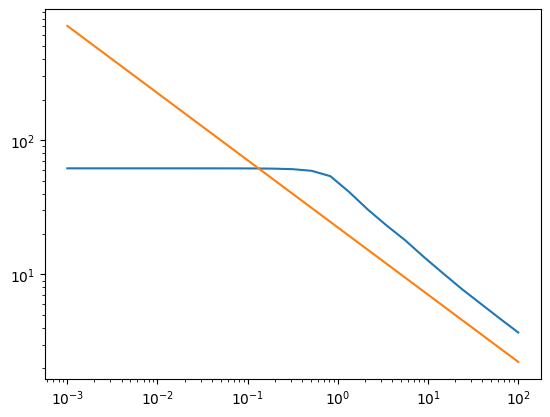

In [437]:
plot(taus,dat)
plot(taus,sqrt(L)*array(taus)**(-1/2))
loglog()

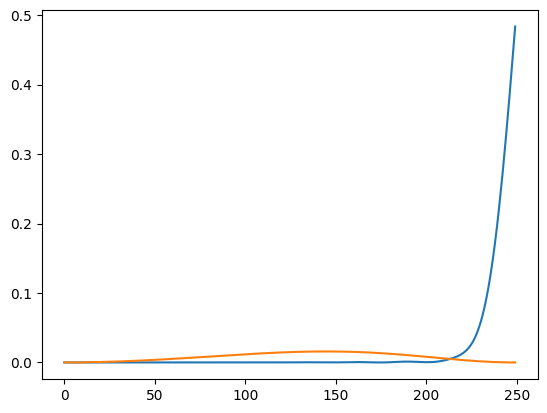

In [400]:

plot(nks(states[0],psi_f))

psi_I= nq.groundstate(0.,L)
nI=nks(psi_I,psi_f)
plot(nI)

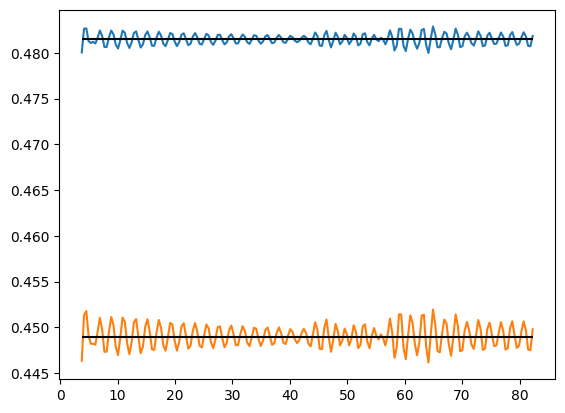

In [271]:
plot(time,P_vector(2,states))

plot(time,P_vector(4,states))

#plot(time,Pz_vector(2,states),ls="--")
#plot(time,Pz_vector(4,states),ls="--")
plt.hlines(Px_n(2,y),time[0],time[-1],color="black")

plt.hlines(Px_n(4,y),time[0],time[-1],color="black")



##plt.hlines(Pz_n(2,y),time[0],time[-1],color="black")


#plt.hlines(Pz_n(4,y),time[0],time[-1],color="black")


In [ ]:
# 1. Define the operator P in Majorana basis
# For P = 0.25 * (1 + sigma1_x + sigma2_x + sigma1_x_sigma2_x)
# Represent this as a matrix M_P
M_P = construct_majorana_matrix_from_pauli_string(P_string)

# 2. Get the Ik matrix in Majorana basis
# K_k is the 2x2 block matrix representing the quasiparticle charge Ik
K_k = construct_K_matrix_for_mode(k, gf)

# 3. Calculate the expectation value
# Using the trace property of Majorana strings:
# <X| Ik |X> = 0.5 * (1 + Tr(K_k @ M_P))
Ik_val = 0.5 * (1 + np.trace(K_k @ M_P)

In [ ]:
groundstate

In [458]:
def get_Ik_expectation_exact(indices, state, L, gf,j):
    """
    indices: List of sites defining your projector P (e.g., [0, 1, 2])
    state: Your quench state parameters [u, v, k_vals]
    k: The specific index of the k-mode to check
    gf: The final g-field value
    """
    # 1. Get Bogoliubov coefficients for the final Hamiltonian at mode k
    # You need your standard TFIM u_k, v_k calculation here
    uk, vk,k = groundstate( gf,L) 
    uk= uk[j]
    vk= vk[j]
    # 2. Represent Ik in the Majorana basis
    # Ik = 0.5 + 0.5i * sum_{m,l} K_ml(k) * c_m * c_l
    # K is the 2x2 matrix representing the Ik operator
    # For a mode k, Ik is expressed in terms of the pair (a_k, b_k)
    # The matrix K in the Majorana basis for this mode is:
    # (assuming standard convention)
    K = np.array([[0, 1], [-1, 0]], dtype=complex) * (uk * np.conj(vk) + vk * np.conj(uk))
    
    # 3. Create the Majorana String for your projector P
    # Your existing function creates the string for the projector
    # Ensure this string is defined for the same sites as 'indices'
    majorana_string_P = op.Create_Majorana_Strings_X(op.binomial_expansion(indices))
    
    # 4. Compute expectation value using Wick's Theorem (Pfaffian)
    # <X| Ik |X> = 0.5 * Tr(P) + 0.5 * i * sum(K_ml * <X| cm cl |X>)
    # Since <X|cm cl|X> are elements of your Covariance Matrix M:
    M = op.Majorana_Covariance(majorana_string_P, state)
    
    # The expectation value of the quadratic part:
    # Use the specific correlations from the Covariance Matrix
    quad_part = 0
    # You need to map the K matrix indices to the M matrix indices
    # This assumes M contains the correlators <cm cl>
    quad_part = 0.5j * (K[0, 1] * M[0, 1] + K[1, 0] * M[1, 0])
    
    return 0.5 + quad_part

In [10]:
L = 50
tau = 1
g0=4
gf = 1/4

psi_0= nq.groundstate(g0,L)
psi_f = nq.groundstate(gf,L)

states,time=free_evo_states(tau,gf,g0,L)

g0=1.0
g0=0.25


In [497]:
var = 0
uf,vf,kf = states[0]
g=gf
for u,v,k in zip(uf,vf,kf):

    H = np.array([
        [2*(g-np.cos(k)),  2j*np.sin(k)],
        [-2j*np.sin(k),   -2*(g-np.cos(k))]
    ], dtype=complex)

    psi = np.array([u,v])

    e1 = psi.conj() @ H @ psi
    e2 = psi.conj() @ (H @ H) @ psi

    var += e2 - e1**2
print(var/L)

(1.0772043953808994-6.369251576159114e-18j)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


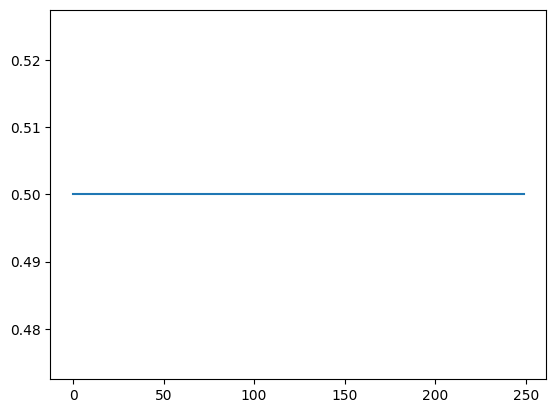

In [476]:
plot([get_Ik_expectation_exact([0,1,2,4],states[0],L,gf,j) for j in range(L//2)])

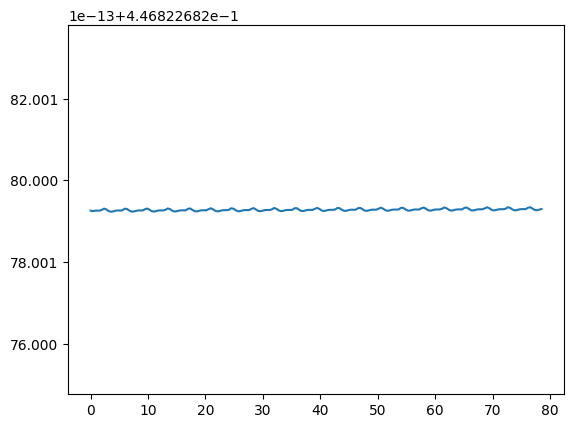

In [179]:
plot(time,-log(P_vector(2,states))/2)

#plot(time,-log(Pz_vector(4,states))/2)

# plot(time,Pz_vector(2,states),ls="--")
# plot(time,Pz_vector(4,states),ls="--")
# plt.hlines(Px_n(2,y),time[0],time[-1],color="black")

# plt.hlines(Px_n(4,y),time[0],time[-1],color="black")



# plt.hlines(Pz_n(2,y),time[0],time[-1],color="black")


# plt.hlines(Pz_n(4,y),time[0],time[-1],color="black")


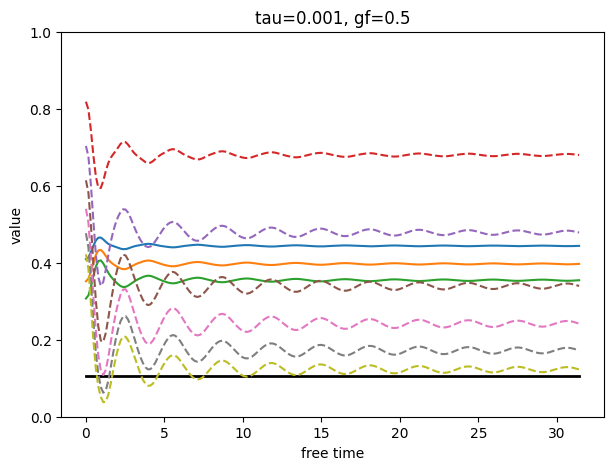

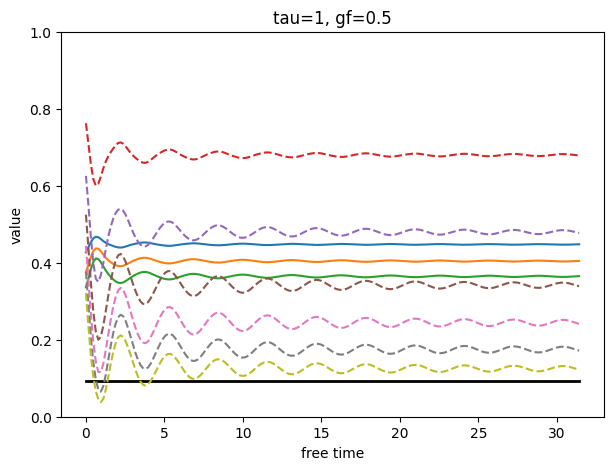

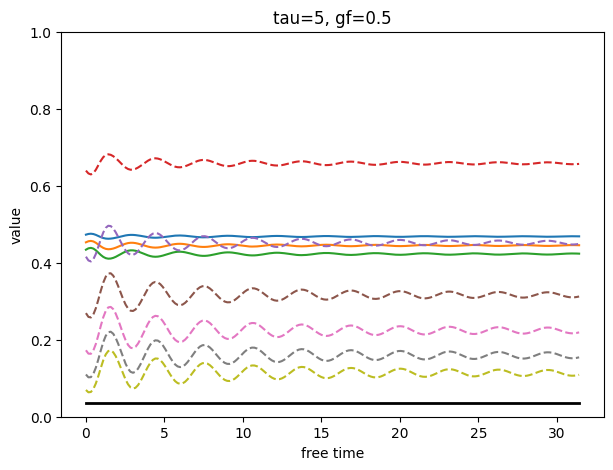

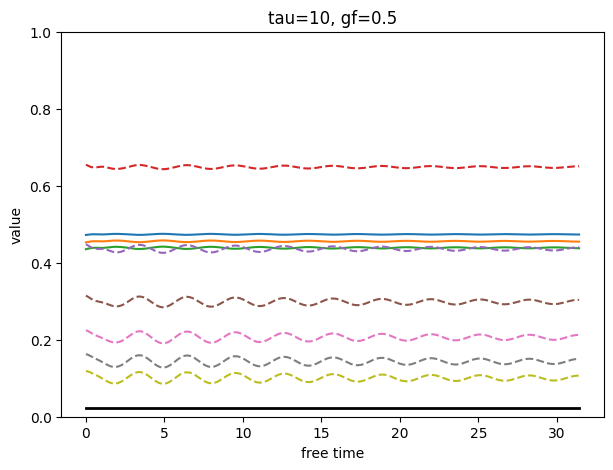

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for (tau, gf), S in dat.items():
    t = free_times[(tau, gf)]
    t = t - t[0]

    plt.figure(figsize=(7,5))

    # entropy
    plt.plot(t, S/L, "k", lw=2, label="Entropy")

    # Px_n
    for n in [2,3,4]:
        Pn = datP[n][(tau, gf)]
        plt.plot(t, (Pn), label=f"Px{n}")

    # Pz_n
    for n in [1,2,3,4,5,6]:
        Pnz = datPz[n][(tau, gf)]
        plt.plot(t, (Pnz), "--", label=f"Pz{n}")

    plt.xlabel("free time")
    plt.ylabel("value")
    plt.title(f"tau={tau}, gf={gf}")
    #plt.legend()
    ylim(0,1)
    plt.show()

In [11]:
import numpy as np

def Majorana_String_sigma_i_I_k_sigma_i1(i, states, L):
    """
    Builds the operator strings for
        σ_i^x γ_k† γ_k σ_{i+1}^x
    in A,B Majorana notation.

    Returns
    -------
    strings : list
        Each element is a list of ("A"/"B", site) tuples representing
        the full Majorana string.
    prefactors : list
        Corresponding complex prefactors including Fourier factors
        and u_k,v_k coefficients.
    """

    strings = []
    prefactors = []
    uf, vf, kf = states
    for uk, vk, k in zip(uf,vf,kf):

        # coefficients appearing in γk† γk
        alpha = (np.conj(uk) - np.conj(vk)) * (uk - vk)
        beta  = (np.conj(uk) - np.conj(vk)) * (uk + vk)
        gamma = (np.conj(uk) + np.conj(vk)) * (uk - vk)
        delta = (np.conj(uk) + np.conj(vk)) * (uk + vk)

        for l in range(L):
            for j in range(L):

                phase = np.exp(1j * k * (l - j)) / (4 * L)

                JW_left  = [("A", m) if t % 2 == 0 else ("B", m)
                            for m in range(i) for t in range(2)]
                JW_right = [("A", m) if t % 2 == 0 else ("B", m)
                            for m in range(i+1) for t in range(2)]

                # four Majorana terms
                terms = [
                    (alpha, [("A", l), ("A", j)]),
                    (-beta, [("A", l), ("B", j)]),
                    (-gamma,[("B", l), ("A", j)]),
                    (delta, [("B", l), ("B", j)])
                ]

                for coeff, core in terms:

                    string = []
                    string += JW_left
                    string += [("A", i)]
                    string += core
                    string += JW_right
                    string += [("A", i+1)]

                    strings.append(string)
                    prefactors.append(coeff * phase)

    return strings, prefactors

In [18]:
terms, pf= Majorana_String_sigma_i_I_k_sigma_i1(0, states[0], L)

In [21]:
L = 10
tau = .001
g0=4
gf = 1/4

psi_0= nq.groundstate(g0,L)
psi_f = nq.groundstate(gf,L)

states,time=free_evo_states(tau,gf,g0,L)

g0=1.0
g0=0.25


In [22]:
dat=0
for term,p in tqdm(zip(terms,pf)):
    dat+=op.Pfaffian(op.Majorana_Covariance(term,states[0])*p)

2000it [00:00, 9309.56it/s]


In [23]:
dat

np.complex128(-0.0013147504124345134-0.00022151614802068195j)

In [28]:
def Create_Majorana_String_sigma_x(i):
    """
    σ_i^x = (Π_{m<i} A_m B_m) A_i
    """
    string = []
    for m in range(i):
        string.append(("A", m))
        string.append(("B", m))
    string.append(("A", i))
    return string


def Create_Px_String(indices):
    """
    Returns list of Majorana strings for Px = ∏ (1+σx)/2
    """
    strings = [[]]   # identity contribution

    for i in indices:
        sx = Create_Majorana_String_sigma_x(i)

        new_strings = []
        for s in strings:
            new_strings.append(s)           # identity term
            new_strings.append(s + sx)      # σx term
        strings = new_strings

    prefactor = 1 / (2 ** len(indices))
    return strings, prefactor

In [52]:
def nk_majorana_terms(state):
    """
    Expands γk† γk into Majorana operators.
    Returns (strings, prefactors).
    """
    uk, vk, k = state

    terms = []
    pref = []

    # |u|^2 c_k† c_k
    terms.append([("ckdag", k), ("ck", k)])
    pref.append(np.conj(uk)*uk)

    # |v|^2 c_-k c_-k†
    terms.append([("ck", -k), ("ckdag", -k)])
    pref.append(np.conj(vk)*vk)

    # uv terms
    terms.append([("ckdag", k), ("ckdag", -k)])
    pref.append(np.conj(uk)*vk)

    terms.append([("ck", -k), ("ck", k)])
    pref.append(np.conj(vk)*uk)

    return terms, pref

In [53]:
def Px_nk_Px(indices, state):
    """
    Builds full operator Px n_k Px as Majorana strings
    """
    Px_strings, Px_pref = Create_Px_String(indices)
    nk_strings, nk_pref = nk_majorana_terms(state)

    total_strings = []
    total_pref = []

    for sL in Px_strings:
        for sN, pN in zip(nk_strings, nk_pref):
            for sR in Px_strings:
                total_strings.append(sL + sN + sR)
                total_pref.append(Px_pref * pN * Px_pref)

    return total_strings, total_pref

In [54]:
op.

SyntaxError: invalid syntax (2697460459.py, line 1)

In [55]:
def Px_nk_Px_expectation(indices, state):
    strings, pref = Px_nk_Px(indices, state)

    val = 0
    for s, p in zip(strings, pref):
        print(s)
        try:
            val += p * (op.Pfaffian(op.Majorana_Covariance(s[0], state)))
        except:
            pass
    return val

In [56]:
L = 10
tau = 1000
g0=4
gf = 1/4

psi_0= nq.groundstate(g0,L)
psi_f = nq.groundstate(gf,L)

states,time=free_evo_states(tau,gf,g0,L)

g0=1.0
g0=0.25


[('ckdag', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339])), ('ck', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339]))]
[('ckdag', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339])), ('ck', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339])), ('A', 0), ('B', 0), ('A', 1), ('B', 1), ('A', 2), ('B', 2), ('A', 3), ('B', 3), ('A', 4)]
[('ckdag', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339])), ('ck', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339])), ('A', 0), ('B', 0), ('A', 1), ('B', 1), ('A', 2), ('B', 2), ('A', 3)]
[('ckdag', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339])), ('ck', array([0.31415927, 0.9424778 , 1.57079633, 2.19911486, 2.82743339])), ('A', 0), ('B', 0), ('A', 1), ('B', 1), ('A', 2), ('B', 2), ('A', 3), ('A', 0), ('B', 0), ('A', 1), ('B', 1), ('A', 2), ('B', 2), ('A', 3), ('B', 3), ('A', 4)]
[('ckdag', array([0.31415927, 0.9424778 , 1.5707

0

In [ ]:
Px_nk_Px_expectation(terms, pf, state)

64

10